### Create anndata object for Ishikawa, 2022 healthy ascending colon that contains LGR5+ stem cells

- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 4th October 2024
- **Last modified date:** 15th November 2024

This notebooks creates anndata object from Ishikawa et al, 2022 dataset, originating from healthy ascending colon. The data was kindly shared with us by the study authors. The data is raw, already filtered, and annotated.

### Import packages

In [1]:
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
from scipy.io import mmread
from scipy.sparse import coo_matrix
import scipy as sci
from datetime import datetime
import json

In [2]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

### Load data

In [3]:
barcodes = pd.read_csv('data/Ishikawa_2022/barcodes.tsv', sep='\t', header=None)
features = pd.read_csv('data/Ishikawa_2022/features.tsv', sep='\t', header=None)

annotation = pd.read_csv('data/Ishikawa_2022/Ishikawa_celltype_annotation.csv', header=0)
embedding = pd.read_csv('data/Ishikawa_2022/Ishikawa_umap_embedding.csv', header=0)

In [4]:
matrix = mmread('data/Ishikawa_2022/matrix.mtx')
matrix = sci.sparse.csr_matrix(matrix)
matrix = np.transpose(matrix)

In [5]:
barcodes.rename(columns={0: 'cell_id'}, inplace=True)
features.rename(columns={0: 'gene_id', 1: 'gene_name', 2: 'gene_type'}, inplace=True)

### Create anndata object from data

In [6]:
adata = ad.AnnData(X=matrix, obs=barcodes, var=features)

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [7]:
X_is_raw(adata)

True

In [8]:
embedding.rename(columns={'Unnamed: 0': 'cell_id'}, inplace=True)
annotation.rename(columns={'Unnamed: 0': 'cell_id'}, inplace=True)

In [9]:
adata = adata[adata.obs['cell_id'].isin(embedding['cell_id'])]

In [10]:
adata.obsm['X_umap'] = embedding.iloc[:, 1:3].values

/tmp/ipykernel_555631/850244365.py:1: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm['X_umap'] = embedding.iloc[:, 1:3].values


In [11]:
adata.obs = pd.merge(adata.obs, annotation, on='cell_id')

### Visualize cell embedding

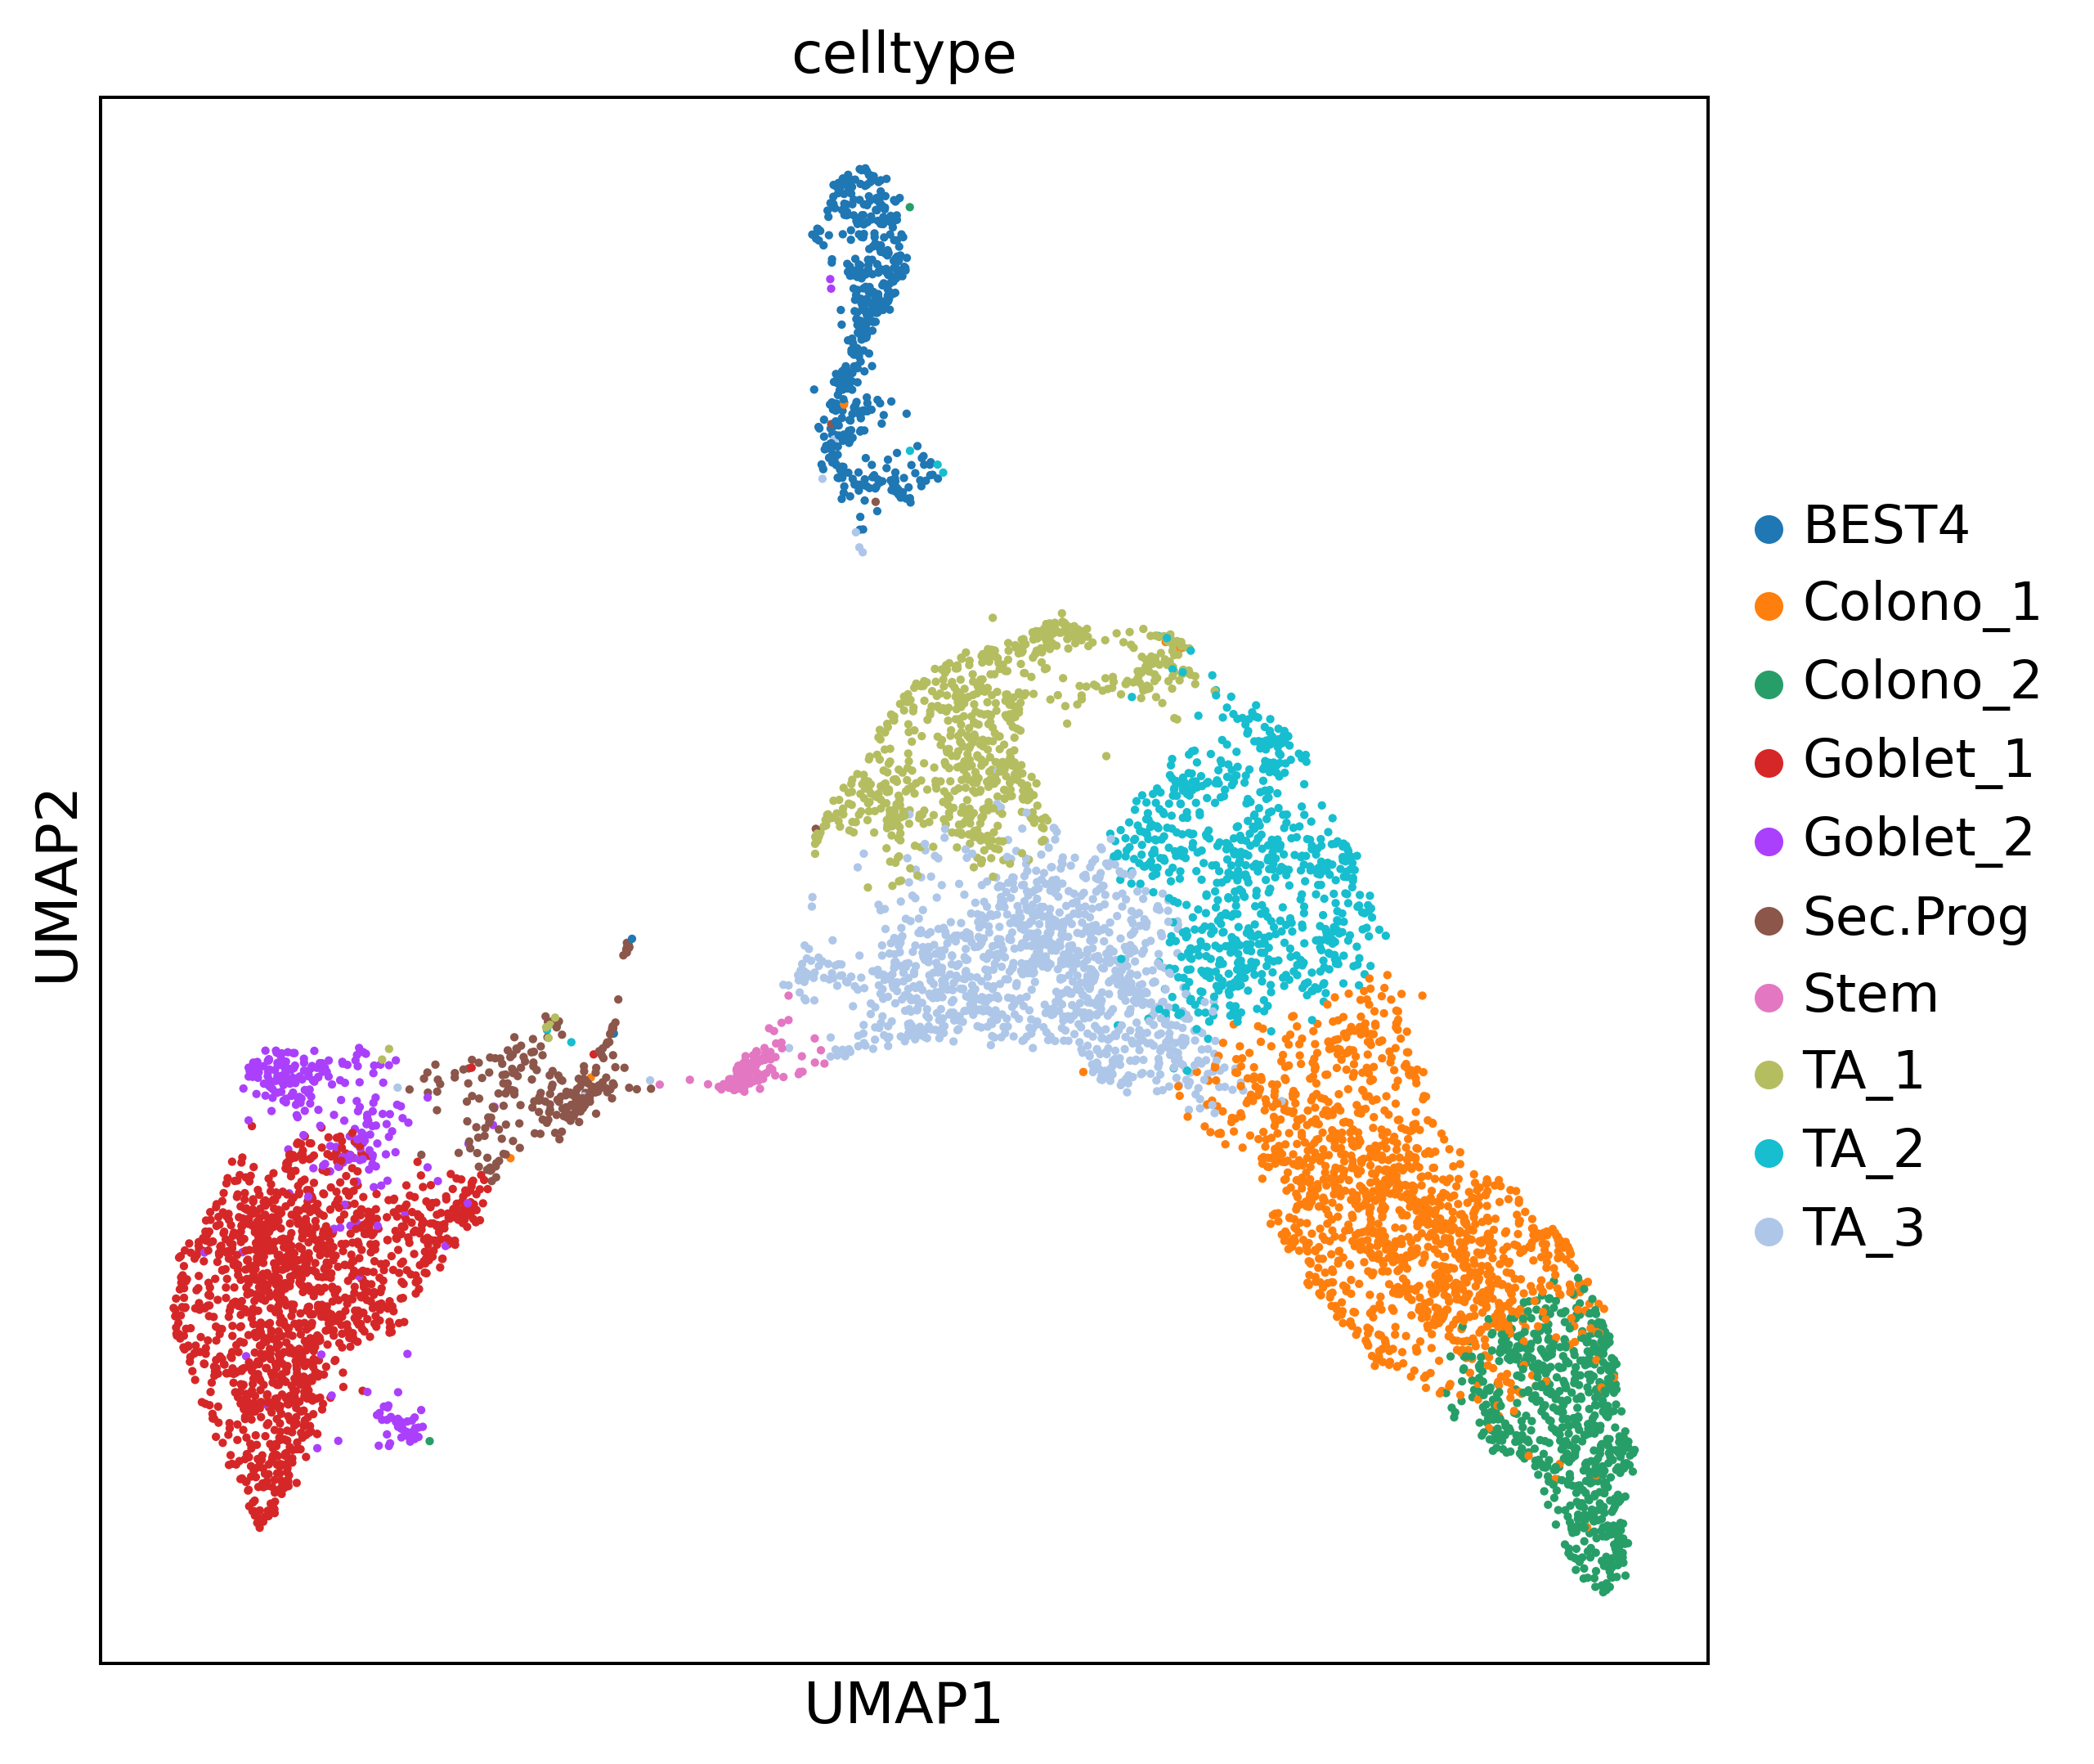

In [12]:
sc.set_figure_params(figsize=(7, 7), dpi=180)
sc.pl.umap(adata, color='celltype')

### Write anndata object

In [14]:
project = 'gut'
species = 'hs'
atribute = 'Ishikawa2022'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
counts = 'raw'

adata.uns['processing_history'] = []
adata.uns['processing_history']={
    'timestamp': timestamp,
    'step': 'anndata object created, data is already filtered and annotated'}

adata.write_h5ad(f"data/Ishikawa_2022/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")